# 🛠️ Chapter 3.3 & 3.5: Other Considerations in the Regression Model

Standard linear regression makes strict assumptions: 

Up to this point, we have assumed:
- All predictors are **quantitative** (numerical)
- Relationships are strictly **linear** (straight lines)
- Predictors don't **interfere** with each other (additive)

**In the real world, data is messy!** This chapter teaches you how to:

| Section | What You'll Learn |
|---------|-------------------|
| **1. Qualitative Predictors** | How to include categorical data (gender, region) in math equations |
| **2. Interaction Effects** | How to model synergy where predictors work together |
| **3. Polynomial Regression** | How to fit curves, not just straight lines |
| **4. The 6 Potential Problems** | How to detect and fix issues that plague regression models |
| **5. Linear Regression vs KNN** | When to use parametric vs non-parametric methods |



## 🔠 1. Qualitative Predictors (Dummy Variables)

### 🤔 The Problem

Not all data is a number! Consider variables like:

| Person | Gender | Student? | Region |
|--------|--------|----------|--------|
| A | Male | Yes | East |
| B | Female | No | West |

**Question:** How can a regression model use text categories? You can't multiply a string by a coefficient!

### ✅ The Solution: Dummy Variables (Indicator Variables)

For a **binary** variable (two levels), we create a single **dummy (indicator) variable** that takes values 0 or 1:

$$x_i = \begin{cases} 1 & \text{if person owns a house} \\ 0 & \text{if person does not own a house} \end{cases}$$

### 📐 The Regression Equation

$$y_i = \beta_0 + \beta_1 x_i + \epsilon_i$$

This single equation actually represents **TWO separate equations**:

| Case | x Value | Equation | Meaning |
|------|---------|----------|---------|
| **Non-Owner** | x = 0 | $y = \beta_0 + \epsilon$ | Baseline group |
| **Owner** | x = 1 | $y = \beta_0 + \beta_1 + \epsilon$ | Baseline + difference |

### 🔍 Coefficient Interpretation

*Analogy:* Think of $\beta_0$ as the "Base Salary" and $\beta_1$ as the "Student Bonus".

| Coefficient | What It Means |
|-------------|---------------|
| **$\beta_0$ (Intercept)** | Average response for the **baseline** group (non-owners, coded as 0) |
| **$\beta_1$ (Slope)** | The **average difference** between owners and non-owners |
| **$\beta_0 + \beta_1$** | Average response for owners |

> 💡 **Key Insight:** $\beta_1$ tells you "How much more/less does the 'Yes' group have compared to the 'No' group?" This is the simplest form of dummy variable regression.

### 📝 Note on Coding Schemes

The choice of which level gets 0 and which gets 1 is **arbitrary** and doesn't affect predictions — only interpretations:
- **Yes=1, No=0**: $\beta_0$ = No average, $\beta_1$ = Yes minus No
- **No=1, Yes=0**: $\beta_0$ = Yes average, $\beta_1$ = No minus Yes
- Both give identical predictions!

In [12]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Set visualization style
sns.set_theme(style="whitegrid")

# Load the ISLR datasets
credit = pd.read_csv(r"D:\Projects\ISLP_withApplicationsInPython\data\credit.csv", index_col=0)
advertising = pd.read_csv(r"D:\Projects\ISLP_withApplicationsInPython\data\advertising.csv", index_col=0)

# Clean the Auto dataset (it often has '?' for missing horsepower)
auto = pd.read_csv(r"D:\Projects\ISLP_withApplicationsInPython\data\auto.csv", index_col=0)
auto = auto.replace('?', np.nan).dropna()
auto['horsepower'] = auto['horsepower'].astype(int)

print("Datasets Loaded Successfully!")

Datasets Loaded Successfully!


## 🏷️ 2. Qualitative Predictors (More Than Two Levels)

### The Problem with Multiple Categories

What if a predictor has **k levels**? (e.g., Region has 3 levels: East, South, West)

**We cannot use just one dummy variable!** Why? Because 0 and 1 can only distinguish TWO groups.

### 📏 The Golden Rule: k−1 Dummy Variables

> **Always create ONE FEWER dummy variable than the number of levels.**

For Region (3 levels: East, South, West), create exactly **2** dummy variables:

$$x_{i1} = \begin{cases} 1 & \text{if person is from South} \\ 0 & \text{otherwise} \end{cases} \quad x_{i2} = \begin{cases} 1 & \text{if person is from West} \\ 0 & \text{otherwise} \end{cases}$$

### 🎯 The Baseline Concept

The level **NOT** given its own dummy variable (East in this case) becomes the **baseline** (or reference category). Every coefficient is interpreted relative to this baseline.

```
Region
├── East  ← BASELINE (no dummy needed — it's the default)
├── South ← x₁ = 1 if South, 0 otherwise
└── West  ← x₂ = 1 if West, 0 otherwise
```

### 📐 The Full Equation

$$y_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \epsilon_i$$

### 📊 How Predictions Work

| Region | $x_1$ (South) | $x_2$ (West) | Predicted Balance |
|--------|:---:|:---:|-------------------|
| **East** (baseline) | 0 | 0 | $\beta_0$ |
| **South** | 1 | 0 | $\beta_0 + \beta_1$ |
| **West** | 0 | 1 | $\beta_0 + \beta_2$ |

### 🔍 Coefficient Interpretation

| Coefficient | Interpretation |
|-------------|----------------|
| **$\beta_0$** | Average credit card balance for the baseline region (East) |
| **$\beta_1$** | Difference: South − East (how much more/less South has vs East) |
| **$\beta_2$** | Difference: West − East (how much more/less West has vs East) |

### ⚠️ The Dummy Variable Trap

If you create dummies for ALL k levels AND include an intercept ($\beta_0$):
$$East + South + West = 1 \quad \text{(always! This is a mathematical identity)}$$

This creates **PERFECT MULTICOLLINEARITY** — the model cannot distinguish $\beta_0$ from the sum of the dummy coefficients. The OLS matrix becomes non-invertible!

> **Solution:** Always drop ONE category when including an intercept. For k categories, use exactly k−1 dummies.

### 🐍 Python Implementation Note
```python
# In pandas: drop_first=True automatically avoids the trap
pd.get_dummies(df, drop_first=True)

# In sklearn: drop='first' does the same
OneHotEncoder(drop='first')
```

In [14]:
# ============================================
# 🔠 QUALITATIVE PREDICTORS DEMONSTRATION
# ============================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Create sample data mimicking the Credit dataset
data = pd.DataFrame({
    'Balance': [400, 600, 350, 700, 500, 450, 620, 380, 550, 480],
    'Income': [40, 65, 30, 80, 50, 35, 70, 32, 55, 42],
    'Student': ['Yes', 'No', 'No', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'Yes'],
    'Region': ['East', 'South', 'West', 'East', 'South', 'East', 'West', 'South', 'East', 'West']
})

print("📊 Original Data:")
display(data)

# ─── METHOD 1: PANDAS ONE-HOT ENCODING ───
print("\n" + "=" * 60)
print("🔧 METHOD 1: ONE-HOT ENCODING WITH PANDAS")
print("=" * 60)

# drop_first=True automatically avoids dummy variable trap!
df_dummies = pd.get_dummies(data, columns=['Student', 'Region'], drop_first=True)
print("Data with Dummy Variables (drop_first=True):")
display(df_dummies)
print("\nNote: 'Student_Yes' = 1 means Student, 0 means Non-Student")
print("Region baseline = East (both Region_South=0 and Region_West=0)")

# ─── METHOD 2: STATSMODELS FORMULA (Automatic Handling) ───
print("\n" + "=" * 60)
print("📈 METHOD 2: STATSMODELS FORMULA API")
print("=" * 60)

# C() tells statsmodels to treat variable as Categorical
# It automatically creates k-1 dummies and avoids the trap!
model = smf.ols('Balance ~ Income + C(Student) + C(Region)', data=data).fit()
print("\nRegression Results:")
print(model.summary().tables[1])

# Interpretation
print("\n🔍 INTERPRETATION:")
print(f"Baseline (Non-Student, East): β₀ = {model.params['Intercept']:.2f}")
print(f"Student effect (Yes vs No):    β = {model.params['C(Student)[T.Yes]']:.2f}")
print(f"South vs East:                 β = {model.params['C(Region)[T.South]']:.2f}")
print(f"West vs East:                  β = {model.params['C(Region)[T.West]']:.2f}")

📊 Original Data:


,Balance,Income,Student,Region
0,400,40,Yes,East
1,600,65,No,South
2,350,30,No,West
3,700,80,Yes,East
4,500,50,No,South
5,450,35,No,East
6,620,70,Yes,West
7,380,32,Yes,South
8,550,55,No,East
9,480,42,Yes,West



🔧 METHOD 1: ONE-HOT ENCODING WITH PANDAS
Data with Dummy Variables (drop_first=True):


,Balance,Income,Student_Yes,Region_South,Region_West
0,400,40,True,False,False
1,600,65,False,True,False
2,350,30,False,False,True
3,700,80,True,False,False
4,500,50,False,True,False
5,450,35,False,False,False
6,620,70,True,False,True
7,380,32,True,True,False
8,550,55,False,False,False
9,480,42,True,False,True



Note: 'Student_Yes' = 1 means Student, 0 means Non-Student
Region baseline = East (both Region_South=0 and Region_West=0)

📈 METHOD 2: STATSMODELS FORMULA API

Regression Results:
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            189.6609     35.113      5.401      0.003      99.400     279.922
C(Student)[T.Yes]    -12.7739     20.397     -0.626      0.559     -65.206      39.658
C(Region)[T.South]   -11.0139     23.616     -0.466      0.661     -71.720      49.692
C(Region)[T.West]     -5.9075     23.877     -0.247      0.814     -67.286      55.471
Income                 6.5091      0.609     10.680      0.000       4.942       8.076

🔍 INTERPRETATION:
Baseline (Non-Student, East): β₀ = 189.66
Student effect (Yes vs No):    β = -12.77
South vs East:                 β = -11.01
West vs East:                  β = -5.91


## 🤝 3. Extensions: Interaction Effects (Synergy)


### The Additive Assumption (And Why It's Often Wrong)

Standard multiple regression assumes **additivity**: the effect of $X_1$ on $Y$ is the same regardless of the value of $X_2$. 
But in reality, variables often have **synergy**. 

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \epsilon$$

This means the effect of $X_1$ on $Y$ is **constant** regardless of the value of $X_2$.

**But real life isn't additive!** In marketing, spending on TV AND Radio together may boost sales MORE than the sum of their individual effects. This extra boost is called **SYNERGY** or an **interaction effect**.

### 📐 The Interaction Model

To capture synergy, we add a new predictor (**product term**) that is the product of $X_1$ and $X_2$:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 (X_1 \times X_2) + \epsilon$$

### 🔍 What $\beta_3$ REALLY Means (The Key Insight!)

Rewrite the equation by grouping $X_1$ terms:
$$Y = \beta_0 + (\beta_1 + \beta_3 X_2)X_1 + \beta_2 X_2 + \epsilon$$

*   **$(\beta_1 + \beta_3 X_2)$**: **This is the new effective  slope for $X_1$ now $\beta_1 + \beta_3 X_2$ — it DEPENDS on the value of $X_2$!**
*   **$\beta_3$ (Interaction Coefficient)**: The increase in the effectiveness of $X_1$ associated with a one-unit increase in $X_2$. 
*   *Analogy:* TV and Radio ads have synergy. $\beta_3$ tells us how much extra sales we get per dollar of TV ads *specifically because* we are also running Radio ads.


| Scenario | Effective TV Slope | Meaning |
|----------|-------------------|---------|
| Radio = 10 (low spending) | $\beta_1 + 10\beta_3$ | Smaller TV effect |
| Radio = 50 (high spending) | $\beta_1 + 50\beta_3$ | Larger TV effect (synergy!) |

If $\beta_3 > 0$: The predictors **reinforce** each other (positive synergy).  
If $\beta_3 < 0$: The predictors **dampen** each other (negative interaction).

### 📊 Visualizing Interaction: Parallel vs Non-Parallel Lines

```
WITHOUT Interaction (Additive Model):     WITH Interaction:
Sales ↑                                   Sales ↑
      |   / Student (same slope)                |   / Student (steeper slope!)
      |  /                                      |  /
      | /                                       | /
      |/ Non-Student                            |/ Non-Student
      └──────────────────→ Income               └──────────────────→ Income
      
      SAME slope for both groups               DIFFERENT slopes!
      Only intercepts differ                   Income affects students MORE
```

### ⚖️ The Hierarchical Principle

> **If you include an interaction term ($X_1 \times X_2$), you MUST also include the main effects ($X_1$ and $X_2$), even if their individual p-values are not statistically significant!** The interaction term is a product of the two; you cannot have the product without the original components.

**Why?** Leaving out main effects fundamentally changes the mathematical meaning of the interaction term — the interaction would absorb the main effects, making interpretation impossible. This is a non-negotiable modeling rule.

### 📝 Statsmodels Formula Shortcut
```python
# These two are EQUIVALENT:
'sales ~ TV + radio + TV:radio'    # Explicit: main effects + interaction
'sales ~ TV * radio'               # Shortcut: * auto-expands to include all
```

In [5]:
# ============================================
# 🤝 INTERACTION EFFECTS DEMONSTRATION
# ============================================

# Load Advertising dataset

advertising = pd.read_csv(r"D:\Projects\ISLP_withApplicationsInPython\data\Advertising.csv", index_col=0)

print("📊 Advertising Dataset:")
display(advertising.head())

# ─── MODEL 1: WITHOUT INTERACTION (Additive) ───
model_additive = smf.ols('sales ~ TV + radio', data=advertising).fit()

# ─── MODEL 2: WITH INTERACTION ───
# TV * radio automatically includes: TV, radio, AND TV:radio
model_interaction = smf.ols('sales ~ TV * radio', data=advertising).fit()

print("=" * 60)
print("📊 COMPARISON: WITH vs WITHOUT INTERACTION")
print("=" * 60)
print(f"\nAdditive Model R²:     {model_additive.rsquared:.4f}")
print(f"Interaction Model R²:  {model_interaction.rsquared:.4f}")
print(f"\nR² Improvement:        {model_interaction.rsquared - model_additive.rsquared:.4f}")
print(f"This interaction captures additional variance!")

print("\n--- Interaction Model Coefficients ---")
print(model_interaction.params)

# ─── DETAILED INTERPRETATION ───
b0, b1, b2, b3 = model_interaction.params
print(f"\n🔍 DETAILED INTERPRETATION:")
print(f"Full Equation:")
print(f"Sales = {b0:.2f} + ({b1:.4f})×TV + ({b2:.4f})×Radio + ({b3:.6f})×(TV×Radio)")
print(f"\nTV effect DEPENDS on Radio spending:")
print(f"  Radio=$10k: TV slope = {b1 + b3*10:.4f}  (smaller effect)")
print(f"  Radio=$30k: TV slope = {b1 + b3*30:.4f}  (medium effect)")
print(f"  Radio=$50k: TV slope = {b1 + b3*50:.4f}  (larger effect — SYNERGY!)")
print(f"\n✅ Conclusion: TV is MORE effective when Radio spending is HIGH!")
print(f"   This is the synergy effect — they work better together!")

📊 Advertising Dataset:


,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


📊 COMPARISON: WITH vs WITHOUT INTERACTION

Additive Model R²:     0.8972
Interaction Model R²:  0.9678

R² Improvement:        0.0706
This interaction captures additional variance!

--- Interaction Model Coefficients ---
Intercept    6.750220
TV           0.019101
radio        0.028860
TV:radio     0.001086
dtype: float64

🔍 DETAILED INTERPRETATION:
Full Equation:
Sales = 6.75 + (0.0191)×TV + (0.0289)×Radio + (0.001086)×(TV×Radio)

TV effect DEPENDS on Radio spending:
  Radio=$10k: TV slope = 0.0300  (smaller effect)
  Radio=$30k: TV slope = 0.0517  (medium effect)
  Radio=$50k: TV slope = 0.0734  (larger effect — SYNERGY!)

✅ Conclusion: TV is MORE effective when Radio spending is HIGH!
   This is the synergy effect — they work better together!


## 📈 4. Extensions: Polynomial Regression (Capturing Curves)

### Why Straight Lines Fail

What if the relationship between $X$ and $Y$ is a **curve**, not a straight line? We can include transformed versions of the predictors!


```
MPG (fuel efficiency)                    Income
  ↑                                       ↑
  |    ●●●                                |          ______
  |  ●●   ●●                              |       __/
  | ●       ●                             |    __/
  |●         ●                            |___/
  └────────────────→ Horsepower           └────────────────→ Experience
  
  A straight line CANNOT capture this!    Income growth slows with experience!
```
Many real-world relationships are **curved**, not straight:

### 📐 The Solution: Add Powers of X as New Predictors

Instead of $Y = \beta_0 + \beta_1 X$ (straight line), use:
$$Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \epsilon$$

This is **Quadratic Regression** — it fits a parabola (U-shape or inverted-U).

For more complex curves:
$$Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \dots + \beta_d X^d + \epsilon$$

### 🧠 CRUCIAL CONCEPT: It's STILL "Linear" Regression!

> **Polynomial Regression is still a LINEAR MODEL because it's linear in the COEFFICIENTS ($\beta_0, \beta_1, \beta_2$), not the predictors!**

Think of it as **feature engineering**:

| Original Data | After Creating New Features |
|---------------|----------------------------|
| X | X, X², X³ |

You're just creating new columns (X², X³) and running regular multiple linear regression on them! The math of OLS works exactly the same way.

### 📊 Model Flexibility vs Overfitting Trade-off

| Polynomial Degree | Shape | Risk |
|-------------------|-------|------|
| **1** (Linear) | Straight line | Underfitting (too simple) |
| **2** (Quadratic) | Simple parabola | Often the sweet spot |
| **3** (Cubic) | S-curve (one bend) | Still reasonable |
| **5+** | Highly wiggly | **OVERFITTING!** Memorizes noise |

### 🧠 Crucial Concept: It's still a "Linear" Model!
Even though the relationship between $mpg$ and $horsepower$ is a non-linear curve (a parabola), the model is **still linear in the parameters** ($\beta_0, \beta_1, \beta_2$). 
*   *Analogy:* You are just giving the model a "curved ruler" instead of a "straight ruler". But the underlying math (Ordinary Least Squares) used to find the best fit is exactly the same!
*   **Bias-Variance Tradeoff:** A degree-2 polynomial captures a simple curve. A degree-20 polynomial will weave perfectly through every data point, but it will be wildly overfit and fail on new data.


📊 AUTO DATASET


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino



Columns:
['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin', 'name']

📊 POLYNOMIAL REGRESSION COMPARISON
Linear (Degree 1):     R² = 0.6059, RSE = 4.91
Quadratic (Degree 2):  R² = 0.6876, RSE = 4.37
5th Degree:            R² = 0.6967, RSE = 4.33

🔍 Key Insight:
Quadratic model improves substantially over Linear.
5th-degree model usually adds very little improvement.
Higher-degree models risk overfitting.


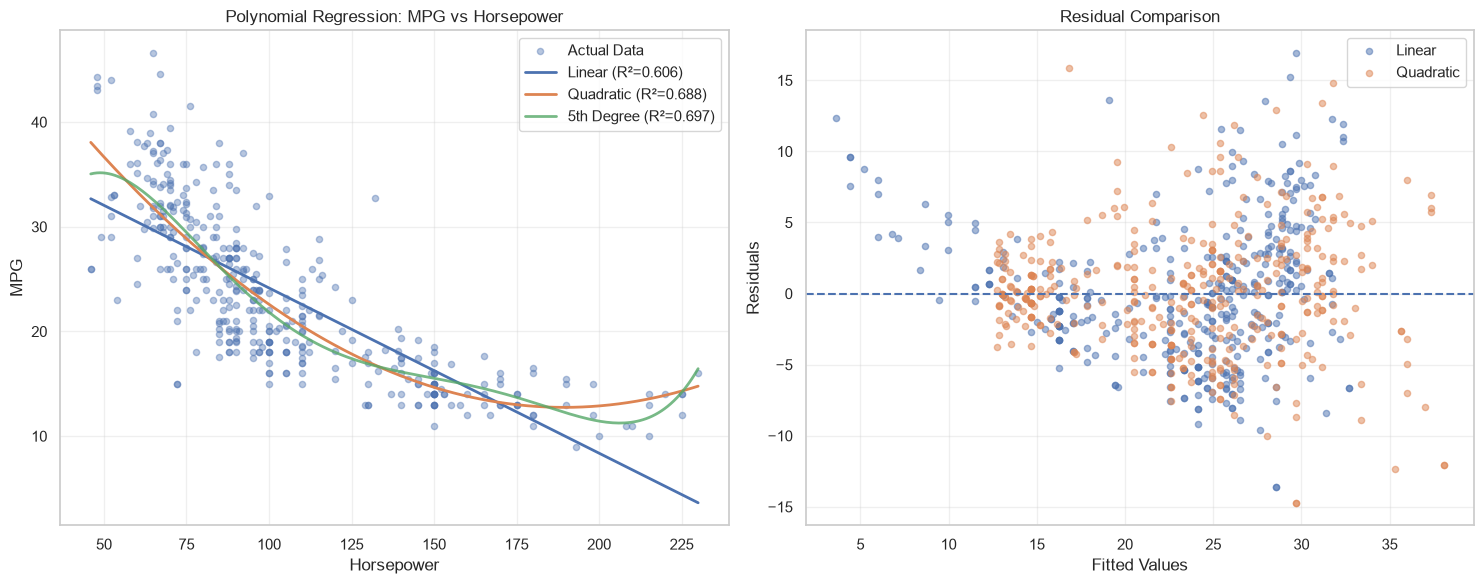


📑 QUADRATIC MODEL SUMMARY
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     428.0
Date:                Fri, 19 Jun 2026   Prob (F-statistic):           5.40e-99
Time:                        15:14:11   Log-Likelihood:                -1133.2
No. Observations:                 392   AIC:                             2272.
Df Residuals:                     389   BIC:                             2284.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept

In [8]:
# ============================================
# 📈 POLYNOMIAL REGRESSION DEMONSTRATION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# ============================================
# LOAD AND CLEAN DATA
# ============================================

auto = pd.read_csv(
    r"D:\Projects\ISLP_withApplicationsInPython\data\Auto.csv"
)

# Remove rows with missing horsepower
auto = auto[auto["horsepower"] != "?"].copy()

# Convert horsepower to numeric
auto["horsepower"] = auto["horsepower"].astype(float)

print("=" * 60)
print("📊 AUTO DATASET")
print("=" * 60)
display(auto.head())

print("\nColumns:")
print(auto.columns.tolist())

# ============================================
# FIT POLYNOMIAL MODELS
# ============================================

model_linear = smf.ols(
    "mpg ~ horsepower",
    data=auto
).fit()

model_quad = smf.ols(
    "mpg ~ horsepower + I(horsepower**2)",
    data=auto
).fit()

model_poly5 = smf.ols(
    """
    mpg ~ horsepower
         + I(horsepower**2)
         + I(horsepower**3)
         + I(horsepower**4)
         + I(horsepower**5)
    """,
    data=auto
).fit()

# ============================================
# MODEL COMPARISON
# ============================================

print("\n" + "=" * 60)
print("📊 POLYNOMIAL REGRESSION COMPARISON")
print("=" * 60)

print(
    f"Linear (Degree 1):     "
    f"R² = {model_linear.rsquared:.4f}, "
    f"RSE = {np.sqrt(model_linear.mse_resid):.2f}"
)

print(
    f"Quadratic (Degree 2):  "
    f"R² = {model_quad.rsquared:.4f}, "
    f"RSE = {np.sqrt(model_quad.mse_resid):.2f}"
)

print(
    f"5th Degree:            "
    f"R² = {model_poly5.rsquared:.4f}, "
    f"RSE = {np.sqrt(model_poly5.mse_resid):.2f}"
)

print("\n🔍 Key Insight:")
print("Quadratic model improves substantially over Linear.")
print("5th-degree model usually adds very little improvement.")
print("Higher-degree models risk overfitting.")

# ============================================
# PREDICTION GRID
# ============================================

hp_range = np.linspace(
    auto["horsepower"].min(),
    auto["horsepower"].max(),
    200
)

pred_df = pd.DataFrame({
    "horsepower": hp_range
})

# ============================================
# VISUALIZATION
# ============================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

# --------------------------------------------
# Plot 1: Fitted Curves
# --------------------------------------------

axes[0].scatter(
    auto["horsepower"],
    auto["mpg"],
    alpha=0.4,
    s=20,
    label="Actual Data"
)

axes[0].plot(
    hp_range,
    model_linear.predict(pred_df),
    linewidth=2,
    label=f"Linear (R²={model_linear.rsquared:.3f})"
)

axes[0].plot(
    hp_range,
    model_quad.predict(pred_df),
    linewidth=2,
    label=f"Quadratic (R²={model_quad.rsquared:.3f})"
)

axes[0].plot(
    hp_range,
    model_poly5.predict(pred_df),
    linewidth=2,
    alpha=0.8,
    label=f"5th Degree (R²={model_poly5.rsquared:.3f})"
)

axes[0].set_xlabel("Horsepower")
axes[0].set_ylabel("MPG")
axes[0].set_title("Polynomial Regression: MPG vs Horsepower")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --------------------------------------------
# Plot 2: Residual Comparison
# --------------------------------------------

axes[1].scatter(
    model_linear.fittedvalues,
    model_linear.resid,
    alpha=0.5,
    s=20,
    label="Linear"
)

axes[1].scatter(
    model_quad.fittedvalues,
    model_quad.resid,
    alpha=0.5,
    s=20,
    label="Quadratic"
)

axes[1].axhline(
    y=0,
    linestyle="--"
)

axes[1].set_xlabel("Fitted Values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residual Comparison")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# MODEL SUMMARIES
# ============================================

print("\n" + "=" * 60)
print("📑 QUADRATIC MODEL SUMMARY")
print("=" * 60)

print(model_quad.summary())

print("\n✅ CONCLUSION")
print("Linear model often shows a U-shaped residual pattern.")
print("Quadratic model captures the curvature.")
print("This provides evidence of a nonlinear relationship.")
print("Polynomial regression is still linear in the coefficients.")

## 🚨 5. The 6 Potential Problems in Linear Regression

When fitting a model, you must act as a detective and check for these 6 common violations:

1. **Non-linearity**: The true relationship isn't a straight line. (Detected via U-shaped residual plots).
2. **Correlation of Error Terms**: Errors are correlated with each other, common in time series. (Leads to falsely narrow confidence intervals).
3. **Non-constant Variance (Heteroscedasticity)**: The variance of the errors changes as $X$ changes. (Detected via a "funnel shape" in residual plots).
4. **Outliers**: Individual data points have an unusually high residual (unusual $Y$). (Detected via Studentized Residuals > 3).
5. **High-Leverage Points**: Individual data points have unusual predictor values (unusual $X$). (Acts like an anchor, pulling the regression line).
6. **Collinearity**: Predictors are highly correlated with each other. (Causes standard errors to explode).

| # | Problem | What Goes Wrong | How to Detect It | How to Fix It |
|---|---------|-----------------|------------------|---------------|
| **1** | **Non-linearity** | Model misses the true curved pattern | Residual vs Fitted plot shows **U-shape** or pattern | Add polynomial terms ($X^2, X^3$) or transform variables |
| **2** | **Correlated Errors** | Standard errors become wrong → bad p-values | Residuals vs Time/Order plot shows **tracking pattern** | Use time series models (ARIMA) or add lag variables |
| **3** | **Heteroscedasticity** | Error variance changes → wrong confidence intervals | Scale-Location plot shows **funnel shape** | Transform Y: $\log(Y)$, $\sqrt{Y}$, or use Weighted Least Squares |
| **4** | **Outliers** | Unusual Y value inflates RSE, lowers R² | **Studentized Residual** > \|3\| | Investigate; remove if data error, keep if legitimate |
| **5** | **High Leverage** | Unusual X value **pulls** the regression line | Leverage $h_i > 2(p+1)/n$ | Investigate; consider robust regression |
| **6** | **Collinearity** | Coefficients become unstable, SEs explode | **VIF > 5-10** or high correlation in matrix | Drop redundant variables or combine them |

### 🔄 The Complete Diagnostic Workflow

```
1. Fit Model
       ↓
2. Residual vs Fitted Plot → Look for U-shape? → If yes: Non-linearity!
       ↓
3. Scale-Location Plot → Look for funnel shape? → If yes: Heteroscedasticity!
       ↓
4. Q-Q Plot → Points off diagonal? → If yes: Non-normality of residuals
       ↓
5. Studentized Residuals → Any > |3|? → If yes: Potential Outliers
       ↓
6. Leverage Statistics → Any > 2(p+1)/n? → If yes: High Leverage Points
       ↓
7. Cook's Distance → Any > 4/n? → If yes: Influential Points
       ↓
8. VIF Calculation → Any > 10? → If yes: Collinearity Problem
       ↓
9. Model is Trustworthy ✅ (or fix issues and re-fit)
```


C:\Users\user\AppData\Local\Temp\ipykernel_7188\2227759072.py:88: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_7188\2227759072.py:88: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
d:\Projects\ISLP_withApplicationsInPython\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Projects\ISLP_withApplicationsInPython\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


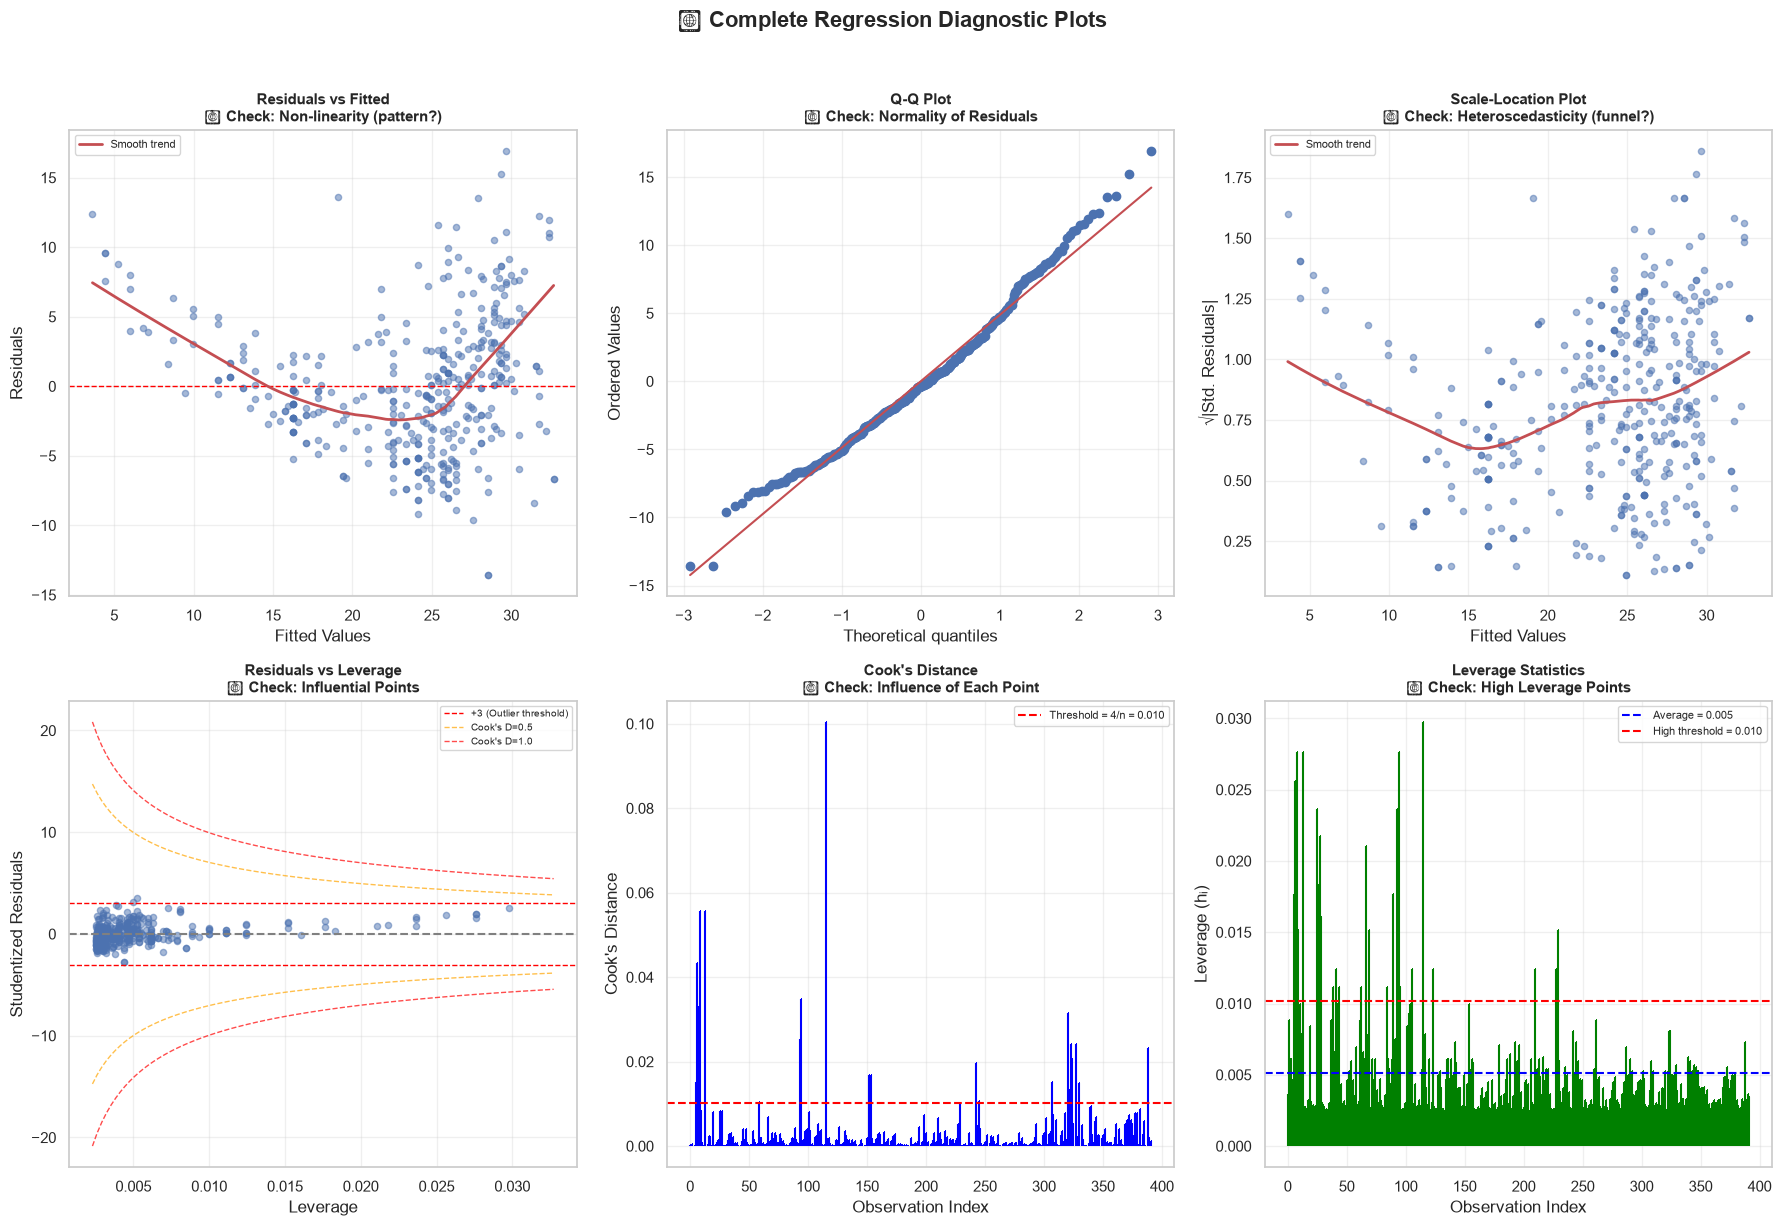

🚨 DIAGNOSTIC SUMMARY
Potential Outliers (|Studentized Residual| > 3): 2 found → indices: [np.int64(320), np.int64(327)]
High Leverage Points (> 2×avg = 0.010): 27 found → indices: [np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(13), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(38), np.int64(41), np.int64(43), np.int64(62), np.int64(66), np.int64(69), np.int64(84), np.int64(89), np.int64(93), np.int64(94), np.int64(95), np.int64(105), np.int64(115), np.int64(123), np.int64(210), np.int64(227), np.int64(229)]
Influential Points (Cook's D > 4/n = 0.010): 21 found → indices: [np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(13), np.int64(58), np.int64(93), np.int64(94), np.int64(115), np.int64(152), np.int64(153), np.int64(242), np.int64(245), np.int64(307), np.int64(320), np.int64(322), np.int64(323), np.int64(324), np.int64(327), np.int64(330), np.int64(388)]

⚠️ Investigate flagged observations before trusting the model!


In [9]:
# ============================================
# 🚨 COMPLETE REGRESSION DIAGNOSTICS
# ============================================

from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy import stats

# Fit a model to diagnose (using Auto dataset)
model_diag = smf.ols('mpg ~ horsepower', data=auto).fit()

# Get all diagnostic measures
influence = model_diag.get_influence()
studentized_residuals = influence.resid_studentized_external
leverage = influence.hat_matrix_diag
cooks_d = influence.cooks_distance[0]
p, n = 1, len(auto)  # 1 predictor, n observations

# Create 2×3 diagnostic plot grid
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# ─── Plot 1: Residuals vs Fitted (Non-linearity Check) ───
axes[0, 0].scatter(model_diag.fittedvalues, model_diag.resid, alpha=0.5, s=20)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1)
smooth = lowess(model_diag.resid, model_diag.fittedvalues)
axes[0, 0].plot(smooth[:, 0], smooth[:, 1], 'r-', linewidth=2, label='Smooth trend')
axes[0, 0].set_title('Residuals vs Fitted\n🔍 Check: Non-linearity (pattern?)', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# ─── Plot 2: Q-Q Plot (Normality Check) ───
stats.probplot(model_diag.resid, dist="norm", plot=axes[0, 1])
axes[0, 1].get_lines()[1].set_markerfacecolor('blue')
axes[0, 1].get_lines()[1].set_markeredgecolor('blue')
axes[0, 1].set_title('Q-Q Plot\n🔍 Check: Normality of Residuals', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# ─── Plot 3: Scale-Location (Heteroscedasticity Check) ───
std_resid_sqrt = np.sqrt(np.abs(influence.resid_studentized_internal))
axes[0, 2].scatter(model_diag.fittedvalues, std_resid_sqrt, alpha=0.5, s=20)
smooth2 = lowess(std_resid_sqrt, model_diag.fittedvalues)
axes[0, 2].plot(smooth2[:, 0], smooth2[:, 1], 'r-', linewidth=2, label='Smooth trend')
axes[0, 2].set_title('Scale-Location Plot\n🔍 Check: Heteroscedasticity (funnel?)', fontsize=11, fontweight='bold')
axes[0, 2].set_xlabel('Fitted Values')
axes[0, 2].set_ylabel('√|Std. Residuals|')
axes[0, 2].legend(fontsize=8)
axes[0, 2].grid(True, alpha=0.3)

# ─── Plot 4: Residuals vs Leverage (Influential Points) ───
axes[1, 0].scatter(leverage, studentized_residuals, alpha=0.5, s=20)
axes[1, 0].axhline(y=0, color='gray', linestyle='--')
axes[1, 0].axhline(y=3, color='red', linestyle='--', linewidth=1, label='+3 (Outlier threshold)')
axes[1, 0].axhline(y=-3, color='red', linestyle='--', linewidth=1)
# Cook's distance contours
x_range = np.linspace(min(leverage)*0.9, max(leverage)*1.1, 100)
for d, color in [(0.5, 'orange'), (1.0, 'red')]:
    y_upper = np.sqrt(d * (1 - x_range) / x_range)
    axes[1, 0].plot(x_range, y_upper, '--', color=color, alpha=0.7, linewidth=1, label=f"Cook's D={d}")
    axes[1, 0].plot(x_range, -y_upper, '--', color=color, alpha=0.7, linewidth=1)
axes[1, 0].set_title('Residuals vs Leverage\n🔍 Check: Influential Points', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Leverage')
axes[1, 0].set_ylabel('Studentized Residuals')
axes[1, 0].legend(fontsize=7)
axes[1, 0].grid(True, alpha=0.3)

# ─── Plot 5: Cook's Distance ───
axes[1, 1].stem(range(len(cooks_d)), cooks_d, markerfmt=',', linefmt='blue', basefmt=' ')
axes[1, 1].axhline(y=4/n, color='red', linestyle='--', linewidth=1.5, label=f'Threshold = 4/n = {4/n:.3f}')
axes[1, 1].set_title("Cook's Distance\n🔍 Check: Influence of Each Point", fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Observation Index')
axes[1, 1].set_ylabel("Cook's Distance")
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

# ─── Plot 6: Leverage Statistics ───
avg_leverage = (p + 1) / n
axes[1, 2].stem(range(len(leverage)), leverage, markerfmt=',', linefmt='green', basefmt=' ')
axes[1, 2].axhline(y=avg_leverage, color='blue', linestyle='--', linewidth=1.5, label=f'Average = {avg_leverage:.3f}')
axes[1, 2].axhline(y=2*avg_leverage, color='red', linestyle='--', linewidth=1.5, label=f'High threshold = {2*avg_leverage:.3f}')
axes[1, 2].set_title('Leverage Statistics\n🔍 Check: High Leverage Points', fontsize=11, fontweight='bold')
axes[1, 2].set_xlabel('Observation Index')
axes[1, 2].set_ylabel('Leverage (hᵢ)')
axes[1, 2].legend(fontsize=8)
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('📊 Complete Regression Diagnostic Plots', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─── PRINT SUMMARY ───
print("=" * 60)
print("🚨 DIAGNOSTIC SUMMARY")
print("=" * 60)

outliers = np.where(np.abs(studentized_residuals) > 3)[0]
high_leverage = np.where(leverage > 2*avg_leverage)[0]
influential = np.where(cooks_d > 4/n)[0]

print(f"Potential Outliers (|Studentized Residual| > 3): {len(outliers)} found → indices: {list(outliers)}")
print(f"High Leverage Points (> 2×avg = {2*avg_leverage:.3f}): {len(high_leverage)} found → indices: {list(high_leverage)}")
print(f"Influential Points (Cook's D > 4/n = {4/n:.3f}): {len(influential)} found → indices: {list(influential)}")

if len(outliers) == 0 and len(high_leverage) == 0 and len(influential) == 0:
    print("\n✅ No major issues detected!")
else:
    print("\n⚠️ Investigate flagged observations before trusting the model!")

## 🔗 7. Collinearity (Multicollinearity)

### 🤔 What Is Collinearity?

**Collinearity** occurs when two or more predictor variables are **highly correlated** with each other. They contain redundant information.

> **The "RSS Valley"**: Geometrically, collinearity creates a long, flat valley in the Residual Sum of Squares contour plot. Many different combinations of $\beta_1$ and $\beta_2$ yield the exact same RSS, causing massive uncertainty (high standard errors) in the coefficient estimates.

**Example from Credit dataset:** `limit` (credit limit) and `rating` (credit rating) are naturally highly correlated — banks give higher limits to higher-rated customers. If you include both, the model gets "confused" about which one deserves credit for predicting balance.

### 📐 Geometric Intuition: The "RSS Valley"

```
WITHOUT Collinearity:              WITH Collinearity:
                                    
  Round RSS contours                 Elongated "valley" RSS contours
     ┌─────────┐                     ┌────────────────────────────┐
     │    ★    │                     │  ★★★★★★★★★★★★★★★★  │
     │         │                     │  ★★★★★★★★★★★★★★★★  │
     └─────────┘                     └────────────────────────────┘
     
  Unique minimum                    Many (β₁, β₂) pairs give
  → Precise coefficient estimates   nearly identical RSS!
                                     → Huge standard errors
                                     → Unstable coefficients
```

### 📊 The Variance Inflation Factor (VIF)

To detect collinearity, we calculate the VIF for each predictor. 
VIF quantifies how much the variance of a coefficient is inflated due to collinearity:

$$VIF(\hat{\beta}_j) = \frac{1}{1 - R^2_{X_j | X_{-j}}}$$

### 🔍 Term Breakdown

| Component | Meaning |
|-----------|---------|
| **$R^2_{X_j \| X_{-j}}$** | R² from regressing predictor $X_j$ on ALL other predictors |
| **VIF = 1** | Zero collinearity — ideal! |
| **VIF = 5** | Moderate concern — SE is $\sqrt{5} \approx 2.23\times$ larger |
| **VIF > 10** | **Serious problem!** — SE is $\sqrt{10} \approx 3.16\times$ larger |

### 💡 Intuition
> If $X_j$ can be **perfectly predicted** from the other predictors, then $R^2 \approx 1$, the denominator $(1-R^2) \to 0$, and **$VIF \to \infty$!** The coefficient becomes completely unidentifiable.

### 🔧 Solutions to Collinearity
1. **Drop one** of the redundant variables (simplest)
2. **Combine** them into a single feature (e.g., average, PCA)
3. Use **regularization** methods (Ridge/Lasso — covered in Chapter 6)


📊 CORRELATION MATRIX
        limit  rating  income
limit   1.000   0.965   0.607
rating  0.965   1.000   0.584
income  0.607   0.584   1.000


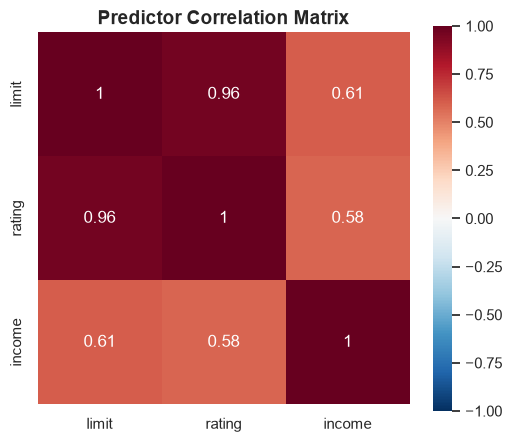


📊 VARIANCE INFLATION FACTORS (VIF)
Feature   VIF                           Status
  const 35.63 🔴 SERIOUS — SE inflated > 3.16×!
  limit 15.39 🔴 SERIOUS — SE inflated > 3.16×!
 rating 14.75 🔴 SERIOUS — SE inflated > 3.16×!
 income  1.58                             🟢 OK

💡 SOLUTION: 'limit' and 'rating' are highly collinear (VIF > 10).
   Drop one of them — the model only needs one to capture creditworthiness!


In [10]:
# ============================================
# 🔗 VIF CALCULATION DEMONSTRATION
# ============================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create synthetic data with known collinearity
np.random.seed(42)
n = 100

# 'limit' is the base variable
limit = np.random.normal(5000, 1000, n)
# 'rating' is HIGHLY correlated with limit (r ≈ 0.97)
rating = limit * 0.8 + np.random.normal(0, 200, n)
# 'income' is moderately correlated with limit
income = limit * 0.01 + np.random.normal(50, 15, n)

X_vif = pd.DataFrame({
    'limit': limit,
    'rating': rating, 
    'income': income
})
X_vif_const = sm.add_constant(X_vif)

# Show correlation matrix
print("=" * 60)
print("📊 CORRELATION MATRIX")
print("=" * 60)
corr = X_vif.corr().round(3)
print(corr)

# Visualize correlation
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Predictor Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()

# Calculate VIF for each feature
print("\n" + "=" * 60)
print("📊 VARIANCE INFLATION FACTORS (VIF)")
print("=" * 60)

vif_data = []
for i, col in enumerate(X_vif_const.columns):
    vif_val = variance_inflation_factor(X_vif_const.values, i)
    if vif_val > 10:
        status = "🔴 SERIOUS — SE inflated > 3.16×!"
    elif vif_val > 5:
        status = "🟡 MODERATE — SE inflated > 2.23×"
    else:
        status = "🟢 OK"
    vif_data.append({'Feature': col, 'VIF': round(vif_val, 2), 'Status': status})

vif_df = pd.DataFrame(vif_data)
print(vif_df.to_string(index=False))

print("\n💡 SOLUTION: 'limit' and 'rating' are highly collinear (VIF > 10).")
print("   Drop one of them — the model only needs one to capture creditworthiness!")

## 🎯 Outliers vs. High Leverage Points — The Critical Difference

These two terms are often confused but mean very different things:

| Feature | Outlier | High Leverage Point |
|---------|---------|---------------------|
| **What's unusual?** | **$Y$ value** (response) is far from prediction | **$X$ value** (predictor) is far from other X values |
| **Residual** | **Large** — point is far from regression line | May be **small** — can be right on the line! |
| **Impact on model** | Inflates RSE, lowers R² | **Pulls regression line** toward itself, changing slopes |
| **Detection tool** | Studentized residual > \|3\| | Leverage $h_i > 2(p+1)/n$ |
| **Visual cue** | Point far above/below other points | Point far to the right/left of other points |

### 📐 The Leverage Statistic Formula (Simple Linear Regression)

$$h_i = \frac{1}{n} + \frac{(x_i - \bar{x})^2}{\sum_{j=1}^n (x_j - \bar{x})^2}$$

### 🔍 Term Breakdown
- **$\frac{1}{n}$**:The absolute minimum leverage any point can have (if it sits exactly at the mean $\bar{x}$).here)
- **$(x_i - \bar{x})^2$**: How far this point's X is from the average X (squared)
- **$\sum (x_j - \bar{x})^2$**: Total variation in X across all points
- **Intuition**: If $x_i$ is an extreme outlier in the X-space, the numerator becomes huge, and $h_i$ approaches 1 → higher leverage. High leverage points act like a heavy person on the end of a seesaw, locking the slope into place.
 
> 💡 **Most dangerous combination:** A point that is BOTH an outlier AND has high leverage — it will dramatically distort your model!

## ⚔️ 6. Parametric vs Non-parametric Methods

### Linear Regression (Parametric)
*   **Assumption:** We assume the mathematical shape is a straight line (or plane).
*   **Pros:** Highly interpretable, easy to compute, provides p-values.
*   **Cons:** If the true relationship is a crazy curve, our assumption is wrong, and predictions will fail.

### K-Nearest Neighbors (KNN) (Non-Parametric)
*   **Assumption:** NONE. It makes no assumptions about the shape of the data.
*   **How it works:** Given a new test point $x_0$, KNN finds the $K$ closest training data points and simply averages their $Y$ values.
$$ \hat{f}(x_0) = \frac{1}{K} \sum_{x_i \in \mathcal{N}_0} y_i $$

### 🌌 The Curse of Dimensionality

> If the true relationship is highly non-linear, KNN dominates Linear Regression. **KNN fails in high dimensions!** As the number of predictors (p) increases, data points become "spread out" in space. The "nearest" neighbors are actually far away, making local averaging meaningless.

 

*   *Analogy:* Finding a friend in a 1D line is easy. Finding them in a 3D city is harder. Finding them in a 100-dimensional hypercube is impossible because the space is so vast that your "nearest" neighbors are actually lightyears away. In high dimensions, KNN has no "local" data to average, leading to terrible predictions.

**Rule of Thumb:** When $p$ is large relative to $n$, parametric methods (Linear Regression) tend to outperform non-parametric methods (KNN).

| Feature | Linear Regression | KNN Regression |
|---------|-------------------|----------------|
| **Type** | **Parametric** | **Non-parametric** |
| **Assumption** | Assumes linear functional form $Y = X\beta$ | Makes NO assumption about shape |
| **What it learns** | Small fixed number of coefficients ($\beta$) | Stores ALL training data |
| **Prediction** | Plug X into equation: $\hat{y} = X\hat{\beta}$ | Average Y of K nearest neighbors |
| **Interpretability** | ✅ Highly interpretable | ❌ Black box |
| **Performance with few obs** | ✅ Works well | ❌ Needs lots of data |
| **Performance in high dimensions** | ✅ Robust (if n > p) | ❌ Suffers from **Curse of Dimensionality** |
| **Best for** | Linear relationships, inference | Highly non-linear relationships |



Linear Regression Test MSE: 0.2156
KNN (K=5) Test MSE:         0.0469

Conclusion: For highly non-linear data, KNN vastly outperforms Linear Regression!


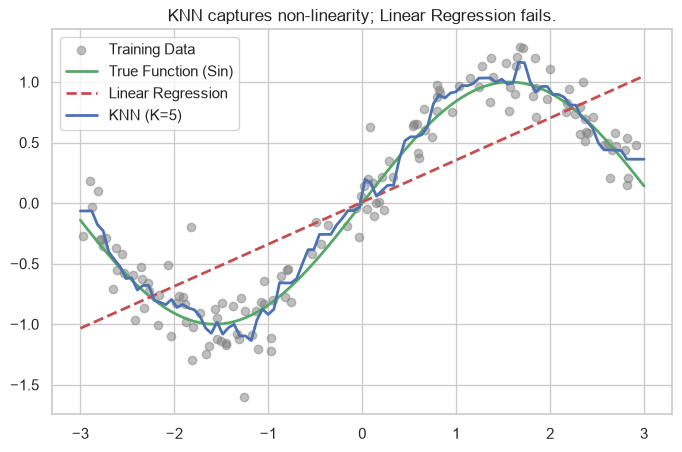

In [16]:
# Generate non-linear 1D data
np.random.seed(42)
X = np.random.uniform(-3, 3, 200).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, 200)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 1. Linear Regression
lin_reg = sm.OLS(y_train, sm.add_constant(X_train)).fit()
y_pred_lin = lin_reg.predict(sm.add_constant(X_test))
mse_lin = mean_squared_error(y_test, y_pred_lin)

# 2. KNN Regression (K=5)
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
mse_knn = mean_squared_error(y_test, y_pred_knn)

print(f"Linear Regression Test MSE: {mse_lin:.4f}")
print(f"KNN (K=5) Test MSE:         {mse_knn:.4f}")
print("\nConclusion: For highly non-linear data, KNN vastly outperforms Linear Regression!")

# Visualizing the fits
X_range = np.linspace(-3, 3, 100).reshape(-1, 1)
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, alpha=0.5, label='Training Data', color='gray')
plt.plot(X_range, np.sin(X_range), 'g-', linewidth=2, label='True Function (Sin)')
plt.plot(X_range, lin_reg.predict(sm.add_constant(X_range)), 'r--', linewidth=2, label='Linear Regression')
plt.plot(X_range, knn.predict(X_range), 'b-', linewidth=2, label='KNN (K=5)')
plt.legend()
plt.title('KNN captures non-linearity; Linear Regression fails.')
plt.show()

## 🎤 Top Interview Questions

### 🟢 Basic Level
**Q1: What is the "Dummy Variable Trap" and why do we use $k-1$ dummies?**
> If you have a categorical variable with $k$ levels and you create $k$ dummy variables, their sum will exactly equal 1 for every observation. This perfectly correlates with the intercept column (which is also all 1s), causing **Perfect Multicollinearity**. The matrix $X^T X$ becomes non-invertible, and the regression math breaks. We drop one category to serve as the "baseline" to avoid this trap.

**Q2: What is an Interaction Effect?**
> When one predictor's effect on Y depends on another predictor's value. Modeled by adding $X_1 \times X_2$ to the equation.

**Q3: Is Polynomial Regression still Linear Regression?**
> YES! It's linear in the coefficients ($\beta$), not the predictors. You're just adding transformed columns like $X^2$.

### 🟡 Intermediate Level
**Q4: What is the Hierarchical Principle?**
> If you include an interaction term (like $X_1 \times X_2$) in a model because it has a significant p-value, you **must** also leave the main effects ($X_1$ and $X_2$) in the model, even if their individual p-values are totally insignificant. Leaving them out changes the mathematical meaning of the interaction term and makes the model dependent on the arbitrary scaling of the variables.

**Q5: Outlier vs High Leverage Point — what's the difference?**
> Outlier = unusual Y value (large residual). High Leverage = unusual X value (pulls the regression line). The most dangerous points are BOTH!
> *   An **Outlier** is a data point with an unusual $Y$ value for its given $X$ (it has a large residual). It typically inflates the model error (RSE) but doesn't radically change the slope of the line.
> *   A **High Leverage Point** is an observation with an extreme, unusual $X$ value. High leverage points act like an anchor or a heavy person on the end of a seesaw; they can drastically alter the entire slope and trajectory of the regression line.

**Q6: What does VIF measure and what threshold is concerning?**
> VIF measures how much collinearity inflates a coefficient's variance. VIF > 5 is moderate concern; VIF > 10 is serious.

### 🔴 Advanced Level
**Q7: Why does collinearity increase standard errors?**
> Creates an elongated "valley" in the RSS surface — many coefficient pairs give nearly identical fit, so estimates become highly uncertain with huge standard errors.

**Q8: How do you detect and fix Heteroscedasticity?**
> It occurs when the variance of the error terms is not constant across all levels of $X$. You spot it by looking at a residual plot; if the residuals fan out into a "funnel shape" as the predicted values increase, you have heteroscedasticity. You fix it by transforming the $Y$ variable using a concave function like $\log(Y)$ or $\sqrt{Y}$ to shrink the larger responses, or by using Weighted Least Squares.

**Q9: Explain the Variance Inflation Factor (VIF) to a non-technical stakeholder.**
> VIF measures how much predictor variables overlap with each other. A high VIF indicates that multiple variables are providing similar information, making coefficient estimates less reliable and harder to interpret, even if the model's predictions remain accurate.

**Q10: What is the Curse of Dimensionality?**
> KNN works by finding the data points closest to your target. However, as the number of dimensions/predictors ($p$) increases, the mathematical distance between all points expands rapidly. In high dimensions, your "nearest" neighbors are actually very far away, destroying the accuracy of the prediction because the model is averaging points that have nothing to do with the target.

**Q11: Why is Polynomial Regression still considered a "Linear" model?**
> Even though it fits a curved line (like a parabola) to the data, it is still considered a **linear model**. This is because the model is linear with respect to the unknown parameters ($\beta_0, \beta_1, \beta_2$). The math used to solve for the coefficients is exactly the same Ordinary Least Squares linear algebra used for straight lines.


---

## 🧠 Fun Facts

1. 🦈 **Ice Cream & Shark Attacks**: Simple regression shows strong positive correlation. Multiple regression adding "Temperature" reveals the truth — temperature drives both!

2. 📏 **Leverage as a Seesaw**: A high-leverage point is like a heavy person at the end of a seesaw — it locks the slope in place. This isn't always bad; it gives the model "anchor points."

3. 📈 **Polynomial Magic**: A 10th-degree polynomial can pass through almost every training point perfectly (R² ≈ 1), but fails catastrophically on new data — a classic overfitting lesson!

4. 📊 **VIF = 5 Impact**: A VIF of 5 means your coefficient's standard error is $\sqrt{5} \approx 2.23$ times larger than it would be with zero collinearity.

5. 🎯 **Automatic Trap Avoidance**: Modern libraries automatically avoid the Dummy Variable Trap — `pd.get_dummies(drop_first=True)` and `OneHotEncoder(drop='first')` are your friends!

6. 🧮 **Origin of "Regression"**: Francis Galton coined the term in the 1880s studying heights — tall parents had children who "regressed" toward average height!

## 🎯 Complete Chapter 3.3 Summary

### Key Concepts Mastered:

| Concept | Key Point | Remember This! |
|---------|-----------|----------------|
| **Dummy Variables** | Convert categories to 0/1 | Use **k−1** dummies for k levels |
| **Baseline Category** | Omitted level for comparison | All coefficients are relative to it |
| **Dummy Variable Trap** | Perfect collinearity from all dummies | Always drop ONE dummy! |
| **Interaction Effects** | $X_1 \times X_2$ product term | Slopes become dependent on other variables |
| **Hierarchical Principle** | Keep main effects with interactions | Non-negotiable modeling rule |
| **Polynomial Regression** | Add $X^2, X^3$ for curves | Still linear in $\beta$ — just feature engineering! |
| **Non-linearity Detection** | U-shape in residual plot | Fix with polynomial terms or transformations |
| **Heteroscedasticity** | Funnel shape in Scale-Location | Fix with $\log(Y)$ or Weighted LS |
| **Outliers** | Unusual Y → large residual | Studentized residual > \|3\| |
| **High Leverage** | Unusual X → pulls line | $h_i > 2(p+1)/n$ |
| **Collinearity** | Predictors correlated | VIF > 10 is serious |
| **Influence** | Point changes model significantly | Cook's Distance > 4/n |
| **KNN vs Linear** | Parametric vs Non-parametric | KNN better for non-linear; fails in high dimensions |

### 🚀 What's Next?
- **Chapter 4: Classification** — Logistic Regression, LDA, QDA
- **Chapter 5: Resampling Methods** — Cross-Validation, Bootstrap
- **Chapter 6: Regularization** — Ridge, Lasso, Elastic Net

> *"Regression diagnostics separate good data scientists from great ones. Always check your assumptions before trusting your model!"* 🚀